In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer # Para convertir texto en una matriz de conteo de palabras

In [23]:
# Dataset de ejemplo para clasificación de spam
df = pd.read_csv('../datasets/spam_ham_es_dataset_v1.csv')
df.head()

,tipo,texto
0,spam,¡Felicidades! Ganaste un iPhone completamente ...
1,spam,Gana $500 al día trabajando desde casa. Regíst...
2,spam,Tu cuenta será suspendida. Verifica tu informa...
3,spam,Oferta limitada: consigue medicamentos con 70%...
4,spam,Has sido seleccionado para un premio exclusivo...


In [24]:
# Convertir texto en una matriz de conteo de palabras (bag-of-words)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["texto"])

In [25]:
print("Vocabulario:", vectorizer.get_feature_names_out()) # Mostrar las características (palabras)

Vocabulario: ['00' '000' '0123' ... 'única' 'úsala' 'útiles']


In [26]:
print("Forma de la matriz de características:", X.shape)  # (n_samples, n_features)

Forma de la matriz de características: (1499, 3495)


In [27]:
# Ejemplo del primer mail
print("Vectorizado:", X.toarray()[0])

Vectorizado: [0 0 0 ... 0 0 0]


In [28]:
# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, df["tipo"], test_size=0.15, random_state=42)

In [29]:
import pickle
import os
# Entrenar el modelo Naive Bayes
model = MultinomialNB(alpha=1.0) # Suavizado de Laplace

# Tratamiento de persistencia del modelo
if os.path.exists('../datasets/spam_classifier_model.pkl'): # Si el modelo ya existe, cargarlo
    with open('../datasets/spam_classifier_model.pkl', 'rb') as model_file:
        model = pickle.load(model_file)
        print("Modelo cargado desde el archivo.")
else: # Si no existe, entrenarlo y guardarlo
    model.fit(X_train, y_train)
    with open('../datasets/spam_classifier_model.pkl', 'wb') as model_file:
        pickle.dump(model, model_file)
        print("Modelo entrenado y guardado en el archivo.")
        
# Hacer predicciones
y_pred = model.predict(X_test)
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

Modelo cargado desde el archivo.
Precisión del modelo: 0.9244444444444444
Reporte de clasificación:
               precision    recall  f1-score   support

         ham       0.89      0.96      0.92       105
        spam       0.96      0.89      0.93       120

    accuracy                           0.92       225
   macro avg       0.92      0.93      0.92       225
weighted avg       0.93      0.92      0.92       225

Matriz de confusión:
 [[101   4]
 [ 13 107]]


<Axes: >

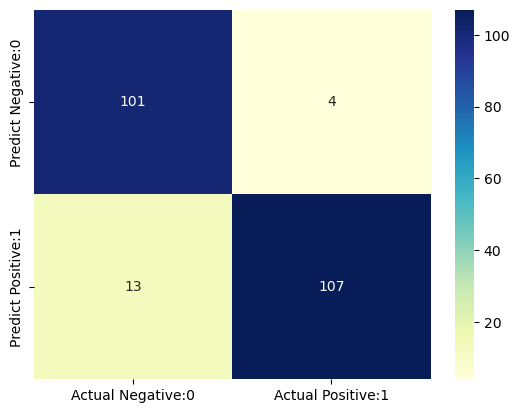

In [30]:
cm = confusion_matrix(y_test, y_pred)
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Negative:0', 'Actual Positive:1'], 
                                 index=['Predict Negative:0', 'Predict Positive:1'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [31]:
# Probar el modelo con un nuevo email
new_email = ["Francisco.Garcia, esto es para ti"]
new_email_vectorized = vectorizer.transform(new_email)
prediction = model.predict(new_email_vectorized)
print("Predicción para el nuevo email:", prediction)  # 1=Spam, 0=No Spam
probabilities = model.predict_proba(new_email_vectorized)
print("Probabilidades de clase para el nuevo email:", probabilities)  # Probabilidades para cada clase

Predicción para el nuevo email: ['ham']
Probabilidades de clase para el nuevo email: [[0.92905388 0.07094612]]
